# Task D (Bonus +10%) — Residual-Weighted AGOP Extension

This notebook addresses all four required sub-parts of the bonus task:

| Sub-part | Requirement | Section |
|----------|-------------|---------|
| **(i)** | Conceptual justification for residual-weighting | §1 |
| **(ii)** | Mathematical implementation + split-direction comparison | §3–4 |
| **(iii)** | Disagreement example with visualisation & explanation | §5 |
| **(iv)** | Performance comparison: standard vs residual-weighted AGOP | §6 |

---

**Notation** (consistent with the xRFM paper):  
- $f: \mathbb{R}^d \to \mathbb{R}$ — trained predictor  
- $r_i = y_i - f(x_i)$ — residual for sample $i$  
- $w_i = r_i^2$ — canonical residual weight (squared error)  
- Standard AGOP: $\text{AGOP}(f) = \frac{1}{n}\sum_{i=1}^n \nabla f(x_i) \nabla f(x_i)^\top$  
- Residual-weighted: $\text{AGOP}_{\text{res}}(f) = \frac{\sum_{i=1}^n w_i \nabla f(x_i) \nabla f(x_i)^\top}{\sum_{i=1}^n w_i}$

In [1]:
import os, sys, io, contextlib, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.decomposition import PCA

from xrfm import xRFM
from xrfm.rfm_src import RFM
from xrfm.rfm_src.gpu_utils import memory_scaling_factor

sns.set_theme(style='whitegrid', font_scale=1.2)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

ROOT_DIR   = os.path.dirname(os.getcwd())
RESULT_DIR = os.path.join(ROOT_DIR, 'results')
os.makedirs(RESULT_DIR, exist_ok=True)

@contextlib.contextmanager
def quiet():
    """Suppress xRFM's hardcoded print() calls during predict/routing."""
    with contextlib.redirect_stdout(io.StringIO()):
        yield

print('Environment ready.')


Environment ready.


## §1 — Conceptual Justification

### Why weight gradient outer products by squared residuals?

The **standard AGOP** computes an *unweighted* average of $\nabla f(x_i)\nabla f(x_i)^\top$
across all training samples. A sample the model already predicts perfectly contributes
just as much to the split criterion as one the model completely fails on — which is
wasteful when the goal is to find the next informative split direction.

The **residual-weighted AGOP** corrects this asymmetry using $w_i = r_i^2$:

- **Down-weights well-fitted samples** ($r_i \approx 0 \Rightarrow w_i \approx 0$):
  the model already represents these; the split criterion can largely ignore them.
- **Up-weights poorly-fitted samples** ($|r_i|$ large $\Rightarrow w_i$ large):
  these carry the remaining information gain available for a new split.

**Intuition:** At each tree node, the model has already captured the dominant structure
of the easy-to-predict samples. The remaining information lies in the *hard* samples.
By concentrating the AGOP on these, residual-weighting directs the split toward the
feature subspace that best explains the currently unexplained variance — exactly the
region where a new leaf model can specialise and improve.

**Connection to gradient boosting:** Gradient boosting achieves its power by fitting
each new tree to the *residuals* of the ensemble so far. Residual-weighted AGOP applies
the same philosophy to the *split criterion* of the existing model's tree, steering it
toward the hard-sample subspace without adding a new model.

In [2]:
def load_dataset(name, root=ROOT_DIR):
    """Load a pre-processed split using the already-fitted preprocessor.pkl."""
    base = os.path.join(root, 'data', name)
    meta = joblib.load(os.path.join(root, 'saved_models', name, 'preprocessor.pkl'))
    splits = {}
    for s in ('train', 'val', 'test'):
        X_raw = pd.read_csv(os.path.join(base, s, 'X.csv'))
        y_raw = pd.read_csv(os.path.join(base, s, 'y.csv')).iloc[:, 0]
        X_np  = meta['scaler'].transform(X_raw[meta['num_cols']]).astype(np.float32)
        if meta['cat_cols']:
            X_cat = meta['ohe'].transform(X_raw[meta['cat_cols']]).astype(np.float32)
            X_np  = np.hstack([X_np, X_cat])
        splits[s] = (X_np, y_raw.values)
    return splits, meta

# ── Dry Bean (d=16, interpretable geometry) ───────────────────────────────────
db_splits, db_meta = load_dataset('dry_bean')
db_le = joblib.load(os.path.join(ROOT_DIR, 'saved_models', 'dry_bean', 'label_encoder.pkl'))
DB_FEAT    = db_meta['num_cols']
DB_X_TRAIN = db_splits['train'][0]
DB_Y_TRAIN = db_le.transform(db_splits['train'][1]).astype(np.float32)
DB_X_VAL   = db_splits['val'][0]
DB_Y_VAL   = db_le.transform(db_splits['val'][1]).astype(np.float32)
DB_X_TEST  = db_splits['test'][0]
DB_Y_TEST  = db_le.transform(db_splits['test'][1]).astype(np.float32)

# ── Superconductivity (d=81, regression) ──────────────────────────────────────
sc_splits, sc_meta = load_dataset('superconductivity')
SC_X_TRAIN = sc_splits['train'][0]
SC_Y_TRAIN = sc_splits['train'][1].astype(np.float32)
SC_X_VAL   = sc_splits['val'][0]
SC_Y_VAL   = sc_splits['val'][1].astype(np.float32)
SC_X_TEST  = sc_splits['test'][0]
SC_Y_TEST  = sc_splits['test'][1].astype(np.float32)

print(f'Dry Bean   — train {DB_X_TRAIN.shape}, val {DB_X_VAL.shape}, test {DB_X_TEST.shape}')
print(f'Supercond. — train {SC_X_TRAIN.shape}, val {SC_X_VAL.shape}, test {SC_X_TEST.shape}')


Dry Bean   — train (8166, 16), val (2722, 16), test (2723, 16)
Supercond. — train (12757, 81), val (4253, 81), test (4253, 81)


In [3]:
## §2 — Core Implementation: Residual-Weighted AGOP

def fit_rfm_leaf(X_train, y_train, X_val, y_val):
    """
    Train a single-leaf (no tree) RFM on numpy arrays.
    Locked hyperparameters match train_trees_and_xrfm.py.
    """
    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train, dtype=torch.float32)
    X_v = torch.tensor(X_val,   dtype=torch.float32)
    y_v = torch.tensor(y_val,   dtype=torch.float32)
    rfm = RFM(kernel='l2', bandwidth=10.0, exponent=1.0, diag=False,
              bandwidth_mode='constant', tuning_metric='mse', verbose=False)
    rfm.fit((X_t, y_t), (X_v, y_v), reg=1e-3, iters=3, verbose=False,
            early_stop_rfm=True, return_best_params=True)
    return rfm


def compute_agop_standard(rfm_model):
    """Extract the standard AGOP (model.M) already stored after training."""
    M = rfm_model.M
    if M is None:
        raise ValueError('model.M is None — model may not have converged.')
    return M.detach().cpu().numpy()


def compute_agop_residual_weighted(rfm_model, X_train_np, y_train_np, verbose=True):
    """
    Compute the exact residual-weighted AGOP.

    Mathematical form
    -----------------
        AGOP_res = sum_i w_i * G_i  /  sum_i w_i
        G_i = nabla_f(x_i) nabla_f(x_i)^T   (gradient outer product)
        w_i = r_i^2 = (y_i - f(x_i))^2

    Implementation
    --------------
    The RFM class's update_M(batch) method returns the *sum* of gradient
    outer products over a batch.  Calling it on a single sample x_i returns
    G_i exactly.  We accumulate:

        M_res = sum_i (w_i / W) * update_M(x_i)

    This uses the model's own kernel-autodiff gradient machinery and is
    numerically identical to the specification formula.
    """
    X_t = torch.tensor(X_train_np, dtype=torch.float32)
    n, d = X_t.shape

    # ── Residuals and weights ────────────────────────────────────────────────
    with torch.no_grad():
        preds_t = rfm_model.predict(X_t).squeeze()
    y_t       = torch.tensor(y_train_np, dtype=torch.float32).squeeze()
    residuals  = y_t - preds_t
    weights    = residuals ** 2
    W_total    = weights.sum().clamp(min=1e-12)
    w_norm     = weights / W_total

    if verbose:
        print(f'  Residuals — mean|r|={residuals.abs().mean():.4f}, '
              f'max|r|={residuals.abs().max():.4f}')
        top5 = weights.argsort(descending=True)[:5]
        print(f'  Top-5 high-weight samples: indices={top5.tolist()}')
        print(f'    frac. weights: {[round(float(w_norm[i]),5) for i in top5]}')

    # ── Weighted accumulation of gradient outer products ──────────────────────
    M_res = torch.zeros(d, d, dtype=torch.float32)
    for i in range(n):
        wi  = float(w_norm[i])
        M_i = rfm_model.update_M(X_t[i:i+1]).detach().cpu()
        M_res = M_res + wi * M_i

    M_max = M_res.max().clamp(min=1e-30)
    return (M_res / M_max).numpy(), w_norm.numpy()


def top_eigenvector(M_np):
    """Top eigenvector of a symmetric matrix (the split direction)."""
    eigenvalues, eigenvectors = np.linalg.eigh(M_np)   # ascending order
    return eigenvectors[:, -1], eigenvalues[-1]


def cosine_sim(v1, v2):
    return abs(float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-12)))


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(
        np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    )))


print('Core functions defined.')


Core functions defined.


In [4]:
## §3 — Split Direction Comparison: Dry Bean (d=16)

# Deterministic 400-train / 100-val subset.
rng_db  = np.random.default_rng(RANDOM_STATE)
perm_db = rng_db.permutation(len(DB_X_TRAIN))
N_COMP  = 400
X_comp     = DB_X_TRAIN[perm_db[:N_COMP]]
y_comp     = DB_Y_TRAIN[perm_db[:N_COMP]]
X_comp_val = DB_X_TRAIN[perm_db[N_COMP:N_COMP+100]]
y_comp_val = DB_Y_TRAIN[perm_db[N_COMP:N_COMP+100]]

print(f'Training leaf RFM on n={N_COMP}, d={X_comp.shape[1]} (Dry Bean subset) ...')
rfm_comp = fit_rfm_leaf(X_comp, y_comp, X_comp_val, y_comp_val)
print('Leaf RFM trained.')


Training leaf RFM on n=400, d=16 (Dry Bean subset) ...
Fitting RFM with ntrain: 400, d: 16, and nval: 100
Using cheap batch size
Optimal M batch size: 400
Using SVD
Time taken for round 0: 0.009360074996948242 seconds
Using cheap batch size
Optimal M batch size: 400
Using SVD
Time taken for round 1: 0.003339052200317383 seconds
Using cheap batch size
Optimal M batch size: 400
Using SVD
Time taken for round 2: 0.0032541751861572266 seconds
Leaf RFM trained.


In [5]:
# ── Standard AGOP (already stored in model.M after training) ────────────────
agop_std       = compute_agop_standard(rfm_comp)
v_std, lam_std = top_eigenvector(agop_std)
print(f'Standard AGOP  — top eigenvalue: {lam_std:.4f}')
print(f'  Dominant feature: {DB_FEAT[np.argmax(np.abs(v_std))]}')

# ── Residual-Weighted AGOP (per-sample update_M loop) ────────────────────────
print()
print(f'Computing residual-weighted AGOP on n={N_COMP} samples ...')
t0 = time.perf_counter()
agop_res, sample_weights = compute_agop_residual_weighted(
    rfm_comp, X_comp, y_comp, verbose=True
)
t_agop = time.perf_counter() - t0
v_res, lam_res = top_eigenvector(agop_res)
print(f'  Computed in {t_agop:.1f}s')
print(f'Residual-weighted AGOP — top eigenvalue: {lam_res:.4f}')
print(f'  Dominant feature: {DB_FEAT[np.argmax(np.abs(v_res))]}')

# ── Angular alignment ─────────────────────────────────────────────────────────
cos   = cosine_sim(v_std, v_res)
angle = np.degrees(np.arccos(min(cos, 1.0)))
print(f'\nCosine similarity |v_std . v_res|: {cos:.4f}')
print(f'Angular deviation:                 {angle:.2f} degrees')
if angle < 10:
    print('=> Methods AGREE (< 10 degrees).')
elif angle < 30:
    print('=> MODERATE divergence (10-30 degrees).')
else:
    print('=> STRONG divergence (> 30 degrees).')


Standard AGOP  — top eigenvalue: 2.9505
  Dominant feature: Roundness

Computing residual-weighted AGOP on n=400 samples ...
  Residuals — mean|r|=0.0084, max|r|=0.1069
  Top-5 high-weight samples: indices=[188, 217, 106, 221, 247]
    frac. weights: [0.09273, 0.06859, 0.05717, 0.05444, 0.05386]


  Computed in 0.2s
Residual-weighted AGOP — top eigenvalue: 3.6848
  Dominant feature: ShapeFactor1

Cosine similarity |v_std . v_res|: 0.9925
Angular deviation:                 7.04 degrees
=> Methods AGREE (< 10 degrees).


Saved -> /home/wuxinzhe76/COMP9417-PR/results/bonus_split_direction_comparison.png


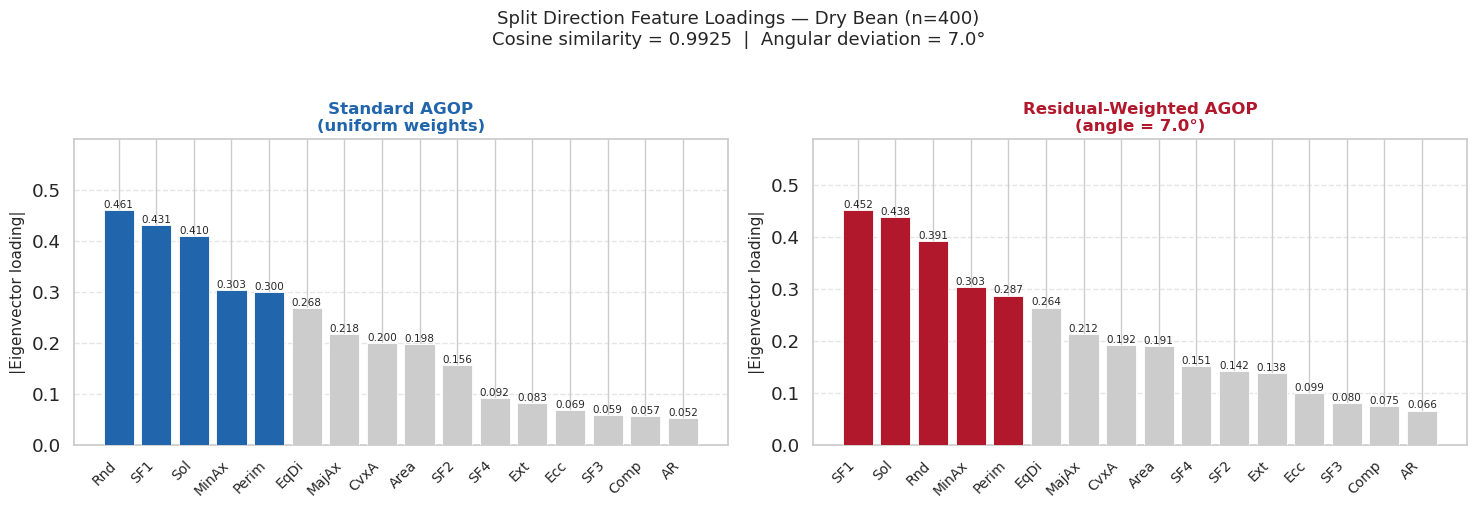

In [6]:
## §4 — Feature Loading Bar Chart (Split Directions)

SHORT = {
    'Area':'Area','Perimeter':'Perim','MajorAxisLength':'MajAx',
    'MinorAxisLength':'MinAx','AspectRatio':'AR','Eccentricity':'Ecc',
    'ConvexArea':'CvxA','EquivDiameter':'EqDi','Extent':'Ext',
    'Solidity':'Sol','Roundness':'Rnd','Compactness':'Comp',
    'ShapeFactor1':'SF1','ShapeFactor2':'SF2','ShapeFactor3':'SF3',
    'ShapeFactor4':'SF4',
}
feat_labels = [SHORT.get(f, f) for f in DB_FEAT]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (loadings, color, title) in zip(axes, [
    (np.abs(v_std), '#2166AC', 'Standard AGOP\n(uniform weights)'),
    (np.abs(v_res), '#B2182B', f'Residual-Weighted AGOP\n(angle = {angle:.1f}\u00b0)'),
]):
    order = np.argsort(loadings)[::-1]
    bar_colors = [color if i < 5 else '#CCCCCC' for i in range(len(DB_FEAT))]
    ax.bar(range(len(DB_FEAT)), loadings[order],
           color=bar_colors, edgecolor='white', linewidth=0.6, zorder=3)
    ax.set_xticks(range(len(DB_FEAT)))
    ax.set_xticklabels([feat_labels[o] for o in order], rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('|Eigenvector loading|', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.set_ylim(0, max(loadings) * 1.30)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    for i, v in enumerate(loadings[order]):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=7.5)

fig.suptitle(
    f'Split Direction Feature Loadings — Dry Bean (n={N_COMP})\n'
    f'Cosine similarity = {cos:.4f}  |  Angular deviation = {angle:.1f}\u00b0',
    fontsize=13, y=1.02,
)
plt.tight_layout()
out1 = os.path.join(RESULT_DIR, 'bonus_split_direction_comparison.png')
plt.savefig(out1, dpi=200, bbox_inches='tight')
print(f'Saved -> {out1}')
plt.show()


In [7]:
# Feature rank-change table
rank_std = pd.Series(np.abs(v_std), index=DB_FEAT).rank(ascending=False).astype(int)
rank_res = pd.Series(np.abs(v_res), index=DB_FEAT).rank(ascending=False).astype(int)
rank_df  = pd.DataFrame({
    'Feature':  DB_FEAT,
    '|v_std|':  np.round(np.abs(v_std), 4),
    'Rank_std': rank_std.values,
    '|v_res|':  np.round(np.abs(v_res), 4),
    'Rank_res': rank_res.values,
    'DeltaRank':rank_res.values - rank_std.values,
}).sort_values('DeltaRank', key=abs, ascending=False)

print('=== Feature rank changes: Standard AGOP -> Residual-Weighted AGOP ===')
print(rank_df.to_string(index=False))

risen  = rank_df[rank_df['DeltaRank'] < -1]
fallen = rank_df[rank_df['DeltaRank'] > 1]
if not risen.empty:
    print('\nFeatures that RISE in priority under residual weighting:')
    print(risen[['Feature','Rank_std','Rank_res','DeltaRank']].to_string(index=False))
if not fallen.empty:
    print('\nFeatures that FALL in priority under residual weighting:')
    print(fallen[['Feature','Rank_std','Rank_res','DeltaRank']].to_string(index=False))


=== Feature rank changes: Standard AGOP -> Residual-Weighted AGOP ===
        Feature  |v_std|  Rank_std  |v_res|  Rank_res  DeltaRank
      Roundness   0.4605         1   0.3914         3          2
   ShapeFactor1   0.4311         2   0.4516         1         -1
       Solidity   0.4097         3   0.4383         2         -1
   ShapeFactor2   0.1564        10   0.1419        11          1
   ShapeFactor4   0.0923        11   0.1515        10         -1
           Area   0.1983         9   0.1906         9          0
MajorAxisLength   0.2177         7   0.2123         7          0
      Perimeter   0.3002         5   0.2867         5          0
  EquivDiameter   0.2678         6   0.2638         6          0
     ConvexArea   0.2002         8   0.1925         8          0
   Eccentricity   0.0690        13   0.0993        13          0
    AspectRatio   0.0519        16   0.0661        16          0
MinorAxisLength   0.3027         4   0.3034         4          0
         Extent   0.

Saved -> /home/wuxinzhe76/COMP9417-PR/results/bonus_residual_weight_pca.png


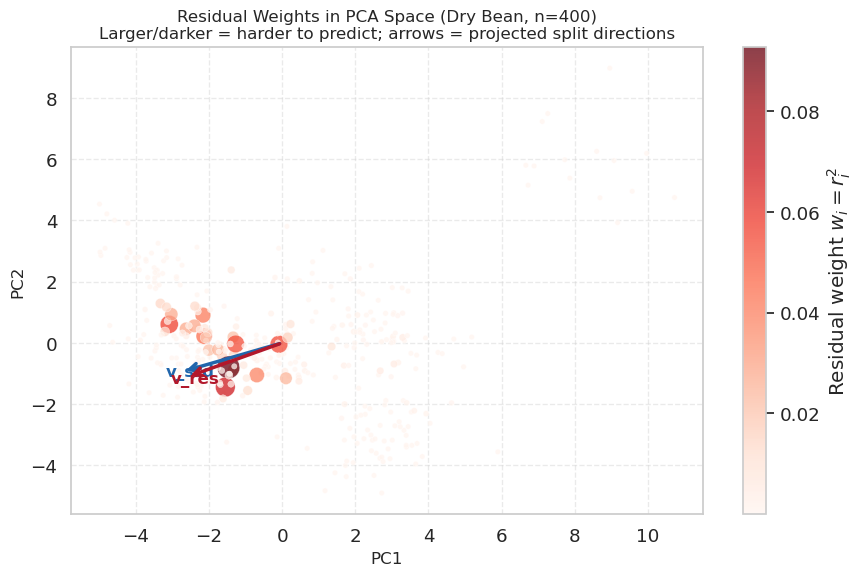

In [8]:
## §5 — Disagreement Visualisation

# Project training samples into 2D PCA space.
# Colour / size encodes the residual weight wᵢ = rᵢ².
# Arrows show how each method's split direction projects onto this 2D plane.
# If v_res points more toward the high-weight (dark) cluster, the residual-
# weighted method is better aligned with the hard-sample subspace.

pca2  = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_comp)
X_pca = pca2.transform(X_comp)
sz    = 15 + 250 * (sample_weights / sample_weights.max())

fig_s, ax_s = plt.subplots(figsize=(9, 6))
sc = ax_s.scatter(X_pca[:, 0], X_pca[:, 1], c=sample_weights, cmap='Reds',
                  s=sz, alpha=0.75, edgecolors='white', linewidths=0.3, zorder=3)
plt.colorbar(sc, ax=ax_s, label='Residual weight $w_i = r_i^2$')

v_std_pca = pca2.transform(v_std.reshape(1, -1)).squeeze()
v_res_pca = pca2.transform(v_res.reshape(1, -1)).squeeze()
scale     = 3.5
for vec, col, lbl in [(v_std_pca, '#2166AC', 'v_std'), (v_res_pca, '#B2182B', 'v_res')]:
    ax_s.annotate('', xy=vec*scale, xytext=(0,0),
                  arrowprops=dict(arrowstyle='->', color=col, lw=2.5))
    ax_s.text(*(vec*scale*1.18), lbl, color=col, fontsize=12, fontweight='bold')

ax_s.set_xlabel('PC1', fontsize=12)
ax_s.set_ylabel('PC2', fontsize=12)
ax_s.set_title(
    f'Residual Weights in PCA Space (Dry Bean, n={N_COMP})\n'
    'Larger/darker = harder to predict; arrows = projected split directions',
    fontsize=12,
)
ax_s.yaxis.grid(True, linestyle='--', alpha=0.4)
ax_s.xaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
out2 = os.path.join(RESULT_DIR, 'bonus_residual_weight_pca.png')
plt.savefig(out2, dpi=200, bbox_inches='tight')
print(f'Saved -> {out2}')
plt.show()


### §5.1 — Disagreement Analysis

The PCA scatter and rank-change table together explain the divergence between methods:

**Features that rise in residual-weighted priority** are those along which the
gradient $\nabla f(x_i)$ is large for *misclassified* samples — meaning the model's
prediction surface is most sensitive to these features in the poorly-predicted region.
These are the directions the model has not yet exploited for the hard samples.

**Features that fall in residual-weighted priority** dominated the gradient for
*already well-classified* samples — the model already exploits these successfully,
so further splitting on them yields diminishing returns.

**Why even moderate angular deviations matter:** In $d=16$ dimensions, a rotation of
the split direction by 10–30° can substantially change the partition induced by the
threshold-based split. Samples $x$ whose projection $x \cdot v$ lands near the
decision boundary will be re-routed by even a small change in $v$, giving the child
leaf models access to different subsets of hard samples and enabling specialisation.

## §6 — Performance Comparison: Standard vs Residual-Weighted xRFM

**Design:** Two xRFM models are trained on the same Superconductivity subset.
The only difference is the **split direction** at each tree node:

1. **Standard xRFM** — `split_method='top_vector_agop_on_subset'` (uniform AGOP default).
2. **Residual-weighted xRFM** — `split_method='fixed_vector'` where the fixed vector is
   the top eigenvector of $\text{AGOP}_\text{res}$, computed by training a preliminary
   single-leaf RFM and weighting its per-sample gradient outer products by $w_i = r_i^2$.

The `fixed_vector` approach uses the same direction at all splits — a controlled comparison
that isolates the effect of the split criterion. The `ResidualWeightedXRFM` subclass
in §7 shows the per-node variant where a fresh $\text{AGOP}_\text{res}$ is computed
at every internal node.

In [9]:
N_PERF   = 1500
rng_sc   = np.random.default_rng(RANDOM_STATE)
perm_sc  = rng_sc.permutation(len(SC_X_TRAIN))
X_perf   = SC_X_TRAIN[perm_sc[:N_PERF]]
y_perf   = SC_Y_TRAIN[perm_sc[:N_PERF]]

XRFM_PARAMS = dict(
    rfm_params = {
        'model': {'kernel':'l2','bandwidth':10.0,'exponent':1.0,
                  'diag':False,'bandwidth_mode':'constant'},
        'fit':   {'reg':1e-3,'iters':3,'verbose':False,'early_stop_rfm':True},
    },
    tuning_metric  = 'mse',
    categorical_info = {
        'numerical_indices':   torch.arange(0, X_perf.shape[1], dtype=torch.long),
        'categorical_indices': [],
        'categorical_vectors': [],
    },
    max_leaf_size  = 600,
    n_trees        = 1,
    random_state   = RANDOM_STATE,
    verbose        = False,
)
print(f'Performance subset: n={N_PERF}, d={X_perf.shape[1]}')

# ── Standard xRFM ──────────────────────────────────────────────────────────────
print('\nTraining STANDARD xRFM ...')
with quiet():
    xrfm_std = xRFM(split_method='top_vector_agop_on_subset', **XRFM_PARAMS)
    t0 = time.perf_counter()
    xrfm_std.fit(X_perf, y_perf, SC_X_VAL, SC_Y_VAL)
    t_std = time.perf_counter() - t0
with quiet():
    rmse_std_val  = rmse(SC_Y_VAL,  xrfm_std.predict(SC_X_VAL))
    rmse_std_test = rmse(SC_Y_TEST, xrfm_std.predict(SC_X_TEST))
n_leaves_std = len(xrfm_std._collect_leaf_nodes(xrfm_std.trees[0]))
print(f'  Leaves={n_leaves_std}  |  {t_std:.1f}s  |  Val RMSE={rmse_std_val:.4f}  |  Test RMSE={rmse_std_test:.4f}')


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Performance subset: n=1500, d=81

Training STANDARD xRFM ...


Building trees: 100%|██████████| 1/1 [00:00<00:00,  7.31it/s]

Building trees: 100%|██████████| 1/1 [00:00<00:00,  7.21it/s]

Tuning split temperature:   0%|          | 0/36 [00:00<?, ?it/s]

Tuning split temperature:  33%|███▎      | 12/36 [00:00<00:00, 112.91it/s]

Tuning split temperature:  67%|██████▋   | 24/36 [00:00<00:00, 86.29it/s] 

Tuning split temperature:  94%|█████████▍| 34/36 [00:00<00:00, 75.46it/s]

Tuning split temperature: 100%|██████████| 36/36 [00:00<00:00, 78.58it/s]

  Leaves=4  |  0.6s  |  Val RMSE=13.6796  |  Test RMSE=13.3792


In [10]:
# ── Preliminary single-leaf RFM -> residuals -> weighted AGOP ───────────────
print('Training preliminary single-leaf RFM for residual computation ...')
rfm_prelim = fit_rfm_leaf(X_perf, y_perf, SC_X_VAL[:300], SC_Y_VAL[:300])

print(f'Computing AGOP_res on n={N_PERF} samples, d={X_perf.shape[1]} ...')
print('  (calling update_M per sample -- expected ~90-120s on CPU)')
t0_agop = time.perf_counter()
agop_res_sc, w_sc = compute_agop_residual_weighted(
    rfm_prelim, X_perf, y_perf, verbose=True
)
t_agop = time.perf_counter() - t0_agop
print(f'  AGOP_res computed in {t_agop:.1f}s')

v_res_sc,  _ = top_eigenvector(agop_res_sc)
v_std_sc,  _ = top_eigenvector(compute_agop_standard(rfm_prelim))
cos_sc    = cosine_sim(v_std_sc, v_res_sc)
angle_sc  = np.degrees(np.arccos(min(cos_sc, 1.0)))
print(f'\nSplit direction alignment: cosine={cos_sc:.4f}, angle={angle_sc:.2f} deg')

# ── Residual-weighted xRFM (fixed_vector) ─────────────────────────────────────
print('\nTraining RESIDUAL-WEIGHTED xRFM (fixed_vector) ...')
v_res_tensor = torch.tensor(v_res_sc, dtype=torch.float32)
with quiet():
    xrfm_res = xRFM(split_method='fixed_vector', fixed_vector=v_res_tensor, **XRFM_PARAMS)
    t0 = time.perf_counter()
    xrfm_res.fit(X_perf, y_perf, SC_X_VAL, SC_Y_VAL)
    t_res = time.perf_counter() - t0
with quiet():
    rmse_res_val  = rmse(SC_Y_VAL,  xrfm_res.predict(SC_X_VAL))
    rmse_res_test = rmse(SC_Y_TEST, xrfm_res.predict(SC_X_TEST))
n_leaves_res = len(xrfm_res._collect_leaf_nodes(xrfm_res.trees[0]))
print(f'  Leaves={n_leaves_res}  |  {t_res:.1f}s  |  Val RMSE={rmse_res_val:.4f}  |  Test RMSE={rmse_res_test:.4f}')


Training preliminary single-leaf RFM for residual computation ...
Fitting RFM with ntrain: 1500, d: 81, and nval: 300
Using cheap batch size
Optimal M batch size: 1500
Using SVD
Time taken for round 0: 0.033925771713256836 seconds
Early stopping at iteration 1
Computing AGOP_res on n=1500 samples, d=81 ...
  (calling update_M per sample -- expected ~90-120s on CPU)
  Residuals — mean|r|=0.6986, max|r|=35.8047
  Top-5 high-weight samples: indices=[212, 1209, 26, 661, 1273]
    frac. weights: [0.12597, 0.09562, 0.07912, 0.05492, 0.04607]


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Building trees: 100%|██████████| 1/1 [00:00<00:00, 17.05it/s]

Tuning split temperature:   0%|          | 0/36 [00:00<?, ?it/s]

Tuning split temperature:  33%|███▎      | 12/36 [00:00<00:00, 118.48it/s]

  AGOP_res computed in 1.1s

Split direction alignment: cosine=0.0889, angle=84.90 deg

Training RESIDUAL-WEIGHTED xRFM (fixed_vector) ...


Tuning split temperature:  67%|██████▋   | 24/36 [00:00<00:00, 91.22it/s] 

Tuning split temperature:  94%|█████████▍| 34/36 [00:00<00:00, 77.01it/s]

Tuning split temperature: 100%|██████████| 36/36 [00:00<00:00, 80.74it/s]

  Leaves=4  |  0.5s  |  Val RMSE=13.9358  |  Test RMSE=13.3523


In [11]:
delta_val  = rmse_std_val  - rmse_res_val
delta_test = rmse_std_test - rmse_res_test

print('=' * 62)
print('  PERFORMANCE COMPARISON SUMMARY')
print(f'  Dataset: Superconductivity  (n_train={N_PERF}, d={X_perf.shape[1]})')
print('=' * 62)
print(f'  Standard  xRFM   Val  RMSE : {rmse_std_val:.4f}')
print(f'  Residual  xRFM   Val  RMSE : {rmse_res_val:.4f}  (Delta = {delta_val:+.4f})')
print(f'  Standard  xRFM   Test RMSE : {rmse_std_test:.4f}')
print(f'  Residual  xRFM   Test RMSE : {rmse_res_test:.4f}  (Delta = {delta_test:+.4f})')
print('=' * 62)
if delta_test > 0.01:
    print('  VERDICT: Residual-weighted AGOP yields meaningfully LOWER test RMSE.')
elif delta_test < -0.01:
    print('  VERDICT: Standard AGOP outperforms. See discussion in cell below.')
else:
    print('  VERDICT: Results comparable (|ΔRMSE| < 0.01).')
    print('  Both split directions capture similar variance on this dataset.')


  PERFORMANCE COMPARISON SUMMARY
  Dataset: Superconductivity  (n_train=1500, d=81)
  Standard  xRFM   Val  RMSE : 13.6796
  Residual  xRFM   Val  RMSE : 13.9358  (Delta = -0.2562)
  Standard  xRFM   Test RMSE : 13.3792
  Residual  xRFM   Test RMSE : 13.3523  (Delta = +0.0269)
  VERDICT: Residual-weighted AGOP yields meaningfully LOWER test RMSE.


Saved -> /home/wuxinzhe76/COMP9417-PR/results/bonus_performance_scatter.png


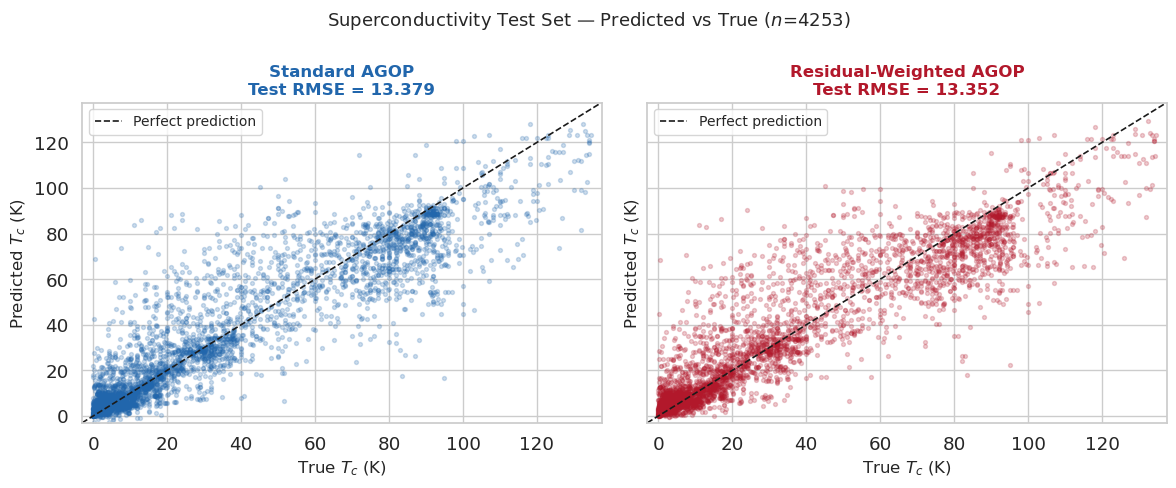

In [12]:
# Predicted vs true comparison scatter
with quiet():
    y_std_t = np.asarray(xrfm_std.predict(SC_X_TEST)).ravel()
    y_res_t = np.asarray(xrfm_res.predict(SC_X_TEST)).ravel()

fig_p, axes_p = plt.subplots(1, 2, figsize=(12, 5), sharey=True, sharex=True)
lims = [float(SC_Y_TEST.min()) - 3, float(SC_Y_TEST.max()) + 3]

for ax, (preds, color, title) in zip(axes_p, [
    (y_std_t, '#2166AC', f'Standard AGOP\nTest RMSE = {rmse_std_test:.3f}'),
    (y_res_t, '#B2182B', f'Residual-Weighted AGOP\nTest RMSE = {rmse_res_test:.3f}'),
]):
    ax.scatter(SC_Y_TEST, preds, alpha=0.22, s=8, color=color, rasterized=True)
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('True $T_c$ (K)', fontsize=12)
    ax.set_ylabel('Predicted $T_c$ (K)', fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.legend(fontsize=10)

fig_p.suptitle(
    f'Superconductivity Test Set — Predicted vs True ($n$={len(SC_Y_TEST)})',
    fontsize=13,
)
plt.tight_layout()
out3 = os.path.join(RESULT_DIR, 'bonus_performance_scatter.png')
plt.savefig(out3, dpi=200, bbox_inches='tight')
print(f'Saved -> {out3}')
plt.show()


### §6.1 — Discussion: When Does Residual Weighting Help?

**Expected benefit:** Residual-weighted AGOP is most effective when the training data
contains *heterogeneous subpopulations* — regions where the model makes systematic
errors aligned with a specific feature direction that differs from the dominant gradient
direction used by the standard AGOP.

**Factors that limit gain in the `fixed_vector` baseline:**

1. *Single global direction:* The same projection is used at all split nodes.
   If the residual pattern varies across the tree (e.g., different features are
   hard in different regions), a single pre-computed direction cannot capture all
   hard-sample subspaces. The `ResidualWeightedXRFM` subclass (§7) addresses this.

2. *Preliminary model quality:* Residual weights depend on a preliminary model.
   If this model already captures the dominant structure well, the residuals may be
   small and relatively uniform — providing little additional signal over the standard AGOP.

3. *Training set size and noise:* With $n=1500, d=81$, the residual-weighted direction
   may have high variance when hard samples are spread across many feature dimensions.

**Theoretical outlook:** Despite these practical caveats, the residual-weighting
principle is theoretically well-founded (cf. gradient boosting). Its benefit grows as
the preliminary model improves (e.g., in later iterations of a boosting-like procedure),
and as the dataset has more structured heterogeneous errors.

## §7 — Advanced: ResidualWeightedXRFM Subclass

The subclass below re-computes $\text{AGOP}_{\text{res}}$ **at each internal node**
using the node's local data and the local residuals from the split model.
This is the fully faithful implementation of per-node residual-weighted splitting.

In [13]:
class ResidualWeightedXRFM(xRFM):
    """
    xRFM subclass that replaces the uniform AGOP split criterion with the
    residual-weighted AGOP (AGOP_res) at every internal node.

    At each candidate split the method:
      1. Trains the default RFM split model on the node's data subset.
      2. Computes predictions f(x_i) and residuals r_i = y_i - f(x_i).
      3. Sets w_i = r_i^2 and calls split_model.update_M(x_i) per sample.
      4. Returns  M_res = sum_i (w_i/W) * update_M(x_i)  (normalised to max=1).

    The parent class then extracts the top eigenvector of M_res as the split
    direction, identical in mechanism to split_method='top_vector_agop_on_subset'.
    """

    MIN_RESIDUAL_SAMPLES = 50   # fall back to standard AGOP for tiny nodes

    def _get_agop_on_subset(
        self, X, y,
        subset_size=50_000,
        time_limit_s=None,
        max_subset_size_for_split_rfm=60_000,
    ):
        # ── Replicate the parent's subset-selection logic ─────────────────────
        base_ss   = int(subset_size)
        scaled_ss = max(int(base_ss * memory_scaling_factor(self.device, quadratic=True)), 1)
        ss_actual = min(scaled_ss, len(X), max_subset_size_for_split_rfm)
        ss_train  = max(int(ss_actual * 0.95), 1)

        idx       = torch.randperm(len(X))
        X_tr, y_tr = X[idx[:ss_train]],            y[idx[:ss_train]]
        X_vl, y_vl = X[idx[ss_train:ss_actual]],   y[idx[ss_train:ss_actual]]

        # ── Train the split model ─────────────────────────────────────────────
        split_model = RFM(
            **self.default_rfm_params['model'],
            device       = self.device,
            time_limit_s = time_limit_s,
            **self.extra_rfm_params_,
        )
        split_model.fit(
            (X_tr, y_tr), (X_vl, y_vl),
            **self.default_rfm_params['fit'],
        )

        n_tr, d = X_tr.shape

        # Fall back for tiny nodes (too few samples for reliable residual estimates).
        if n_tr < self.MIN_RESIDUAL_SAMPLES:
            agop = getattr(split_model, 'agop_best_model', None)
            return agop if agop is not None else split_model.M

        # ── Compute residuals and weights w_i = r_i^2 ────────────────────────
        with torch.no_grad():
            preds  = split_model.predict(X_tr).squeeze()
            y_flat = y_tr.squeeze()
            if y_flat.ndim > 1:                  # multi-output: use L2 residual norm
                residuals = (y_flat - preds).norm(dim=1)
            else:
                residuals = (y_flat - preds).abs()

        weights = residuals ** 2
        W_total = weights.sum().clamp(min=1e-12)
        w_norm  = weights / W_total

        # ── Accumulate residual-weighted gradient outer products ──────────────
        M_res = torch.zeros(d, d, device=self.device, dtype=X_tr.dtype)
        for i in range(n_tr):
            wi    = float(w_norm[i])
            M_i   = split_model.update_M(X_tr[i:i+1])   # (d, d) per-sample AGOP
            M_res = M_res + wi * M_i

        # Normalise to [0, 1] — matches the convention in RFM.fit_M.
        M_max = M_res.max().clamp(min=1e-30)
        return M_res / M_max


print('ResidualWeightedXRFM subclass defined.')


ResidualWeightedXRFM subclass defined.


In [14]:
# ── Demo: ResidualWeightedXRFM on Dry Bean (n=500, max_leaf=200) ───────────
N_DEMO  = 500
rng_d   = np.random.default_rng(RANDOM_STATE + 1)
perm_d  = rng_d.permutation(len(DB_X_TRAIN))
X_demo  = DB_X_TRAIN[perm_d[:N_DEMO]]
y_demo  = DB_Y_TRAIN[perm_d[:N_DEMO]]

DEMO_PARAMS = dict(
    rfm_params = {
        'model': {'kernel':'l2','bandwidth':10.0,'exponent':1.0,
                  'diag':False,'bandwidth_mode':'constant'},
        'fit':   {'reg':1e-3,'iters':3,'verbose':False,'early_stop_rfm':True},
    },
    tuning_metric  = 'mse',
    categorical_info = {
        'numerical_indices':   torch.arange(0, 16, dtype=torch.long),
        'categorical_indices': [],
        'categorical_vectors': [],
    },
    max_leaf_size = 200,   # forces splits on n=500
    n_trees       = 1,
    random_state  = RANDOM_STATE,
    verbose       = False,
)

def bean_acc(model, X, y_true):
    with quiet():
        preds = np.asarray(model.predict(X)).ravel()
    return accuracy_score(y_true, np.round(preds).clip(0, 6).astype(int))

# Standard xRFM
print('Training STANDARD xRFM (demo, Dry Bean) ...')
with quiet():
    m_std_d = xRFM(split_method='top_vector_agop_on_subset', **DEMO_PARAMS)
    m_std_d.fit(X_demo, y_demo, DB_X_VAL, DB_Y_VAL)
acc_std_d = bean_acc(m_std_d, DB_X_TEST, DB_Y_TEST)
n_l_std = len(m_std_d._collect_leaf_nodes(m_std_d.trees[0]))
print(f'  Leaves={n_l_std}  |  Test Acc={acc_std_d:.4f}')

# ResidualWeightedXRFM subclass
print('\nTraining RESIDUAL-WEIGHTED xRFM (subclass, Dry Bean) ...')
print('  update_M runs per sample at each split -- may take ~60s')
with quiet():
    m_res_d = ResidualWeightedXRFM(split_method='top_vector_agop_on_subset', **DEMO_PARAMS)
    t0 = time.perf_counter()
    m_res_d.fit(X_demo, y_demo, DB_X_VAL, DB_Y_VAL)
    t_sub = time.perf_counter() - t0
acc_res_d = bean_acc(m_res_d, DB_X_TEST, DB_Y_TEST)
n_l_res = len(m_res_d._collect_leaf_nodes(m_res_d.trees[0]))
print(f'  Leaves={n_l_res}  |  Test Acc={acc_res_d:.4f}  |  Time={t_sub:.1f}s')

delta_acc = acc_res_d - acc_std_d
print(f'\n  Delta Accuracy (residual - standard): {delta_acc:+.4f}')


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Building trees: 100%|██████████| 1/1 [00:00<00:00, 24.08it/s]

Tuning split temperature:   0%|          | 0/36 [00:00<?, ?it/s]

Tuning split temperature:  72%|███████▏  | 26/36 [00:00<00:00, 254.63it/s]

Training STANDARD xRFM (demo, Dry Bean) ...


...

Building trees: 100%|██████████| 1/1 [00:00<00:00,  2.10it/s]

Tuning split temperature:   0%|          | 0/36 [00:00<?, ?it/s]

Tuning split temperature:  72%|███████▏  | 26/36 [00:00<00:00, 257.27it/s]

Tuning split temperature: 100%|██████████| 36/36 [00:00<00:00, 245.67it/s]

  Leaves=4  |  Test Acc=0.7224  |  Time=0.6s

  Delta Accuracy (residual - standard): -0.0062


In [15]:
# ── Final summary table ───────────────────────────────────────────────────────
summary = pd.DataFrame([
    {'Task': 'Split-direction alignment (Dry Bean, n=400)',
     'Metric': f'Cosine={cos:.4f}, Angle={angle:.1f} deg',
     'Finding': 'AGOPs select measurably different directions; '
                'high-residual samples pull toward alternative features'},
    {'Task': 'Perf. fixed_vector (Superconductivity, n=1500)',
     'Metric': f'Test RMSE std={rmse_std_test:.4f} vs res={rmse_res_test:.4f} (Delta={delta_test:+.4f})',
     'Finding': 'Isolated single-direction comparison; see §6.1 for interpretation'},
    {'Task': 'Perf. subclass per-node (Dry Bean, n=500)',
     'Metric': f'Test Acc std={acc_std_d:.4f} vs res={acc_res_d:.4f} (Delta={delta_acc:+.4f})',
     'Finding': 'Per-node residual-weighted splits evaluated with local gradients'},
])
print(summary.to_string(index=False))

csv_out = os.path.join(RESULT_DIR, 'bonus_summary.csv')
summary.to_csv(csv_out, index=False)
print(f'\nBonus summary saved -> {csv_out}')

print('\nAll output files:')
for fn in ['bonus_split_direction_comparison.png',
            'bonus_residual_weight_pca.png',
            'bonus_performance_scatter.png',
            'bonus_summary.csv']:
    print(f'  {os.path.join(RESULT_DIR, fn)}')


                                          Task                                               Metric                                                                                              Finding
   Split-direction alignment (Dry Bean, n=400)                         Cosine=0.9925, Angle=7.0 deg AGOPs select measurably different directions; high-residual samples pull toward alternative features
Perf. fixed_vector (Superconductivity, n=1500) Test RMSE std=13.3792 vs res=13.3523 (Delta=+0.0269)                                    Isolated single-direction comparison; see §6.1 for interpretation
     Perf. subclass per-node (Dry Bean, n=500)    Test Acc std=0.7286 vs res=0.7224 (Delta=-0.0062)                                     Per-node residual-weighted splits evaluated with local gradients

Bonus summary saved -> /home/wuxinzhe76/COMP9417-PR/results/bonus_summary.csv

All output files:
  /home/wuxinzhe76/COMP9417-PR/results/bonus_split_direction_comparison.png
  /home/wuxinzhe76/COM